# METIS AI 스케일업 — 1st/2nd day 통합 분석 (Google Colab)

`MyDrive/microbiome_team1`의 `result1_1st.csv`, `result1_2nd.csv`를 각각 동일한 파이프라인으로 분석합니다.

- 날짜별 결과: `METIS_1st_2nd_results/1st_day`, `2nd_day`
- 날짜 비교 결과: `METIS_1st_2nd_results/comparison`
- 두 날짜 통합 모델 결과: `METIS_1st_2nd_results/combined`

파일명은 대소문자를 구분하지 않고 찾습니다. 입력 CSV에는 `Peptone`, `Meat`, `Yeast`, `Glucose`, `yield` 열이 있어야 합니다.

In [1]:
# Colab 환경 준비
from google.colab import drive
drive.mount('/content/drive')

!pip -q install xgboost
!wget -q -O /content/utils.py https://raw.githubusercontent.com/amirpandi/METIS/main/utils.py

import os, math, random, time, warnings
from pathlib import Path
from itertools import combinations

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import spearmanr, pearsonr
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import RandomizedSearchCV, KFold
from xgboost import XGBRegressor
from utils import *

warnings.filterwarnings('ignore')
pd.options.mode.chained_assignment = None
sns.set_theme(style='whitegrid', context='notebook')

BASE_DIR = Path('/content/drive/MyDrive/microbiome_team1')
OUT_DIR = BASE_DIR / 'METIS_1st_2nd_results'
for p in [OUT_DIR/'1st_day', OUT_DIR/'2nd_day', OUT_DIR/'comparison', OUT_DIR/'combined']:
    p.mkdir(parents=True, exist_ok=True)
print('입력 폴더:', BASE_DIR)
print('출력 폴더:', OUT_DIR)

Mounted at /content/drive
입력 폴더: /content/drive/MyDrive/microbiome_team1
출력 폴더: /content/drive/MyDrive/microbiome_team1/METIS_1st_2nd_results


## 분석 설정

원본 노트북의 농도 범위와 모델 설정을 유지했습니다. 재현성을 위해 난수 시드를 고정했습니다.

In [2]:
SEED = 42
np.random.seed(SEED)
random.seed(SEED)

m = 4
minimum_drop_size_nanoliter = 1000
final_reaction_volume_nanoliter = 1_000_000
maximum_volume_of_model_output = 750_000
fixed_parts = {'Fixed': 0.25}
n_iter = 200
ensemble_len = 20

concentrations_limits = {
    'Peptone': {'Conc_Min': None, 'Conc_Max': None, 'Conc_Values': [1.0, 5.0, 10.0, 20.0], 'Conc_Stock': 200.0, 'Alternatives': None},
    'Meat':    {'Conc_Min': 0.0, 'Conc_Max': 16.0, 'Conc_Values': None, 'Conc_Stock': 160.0, 'Alternatives': None},
    'Yeast':   {'Conc_Min': 0.0, 'Conc_Max': 8.0,  'Conc_Values': None, 'Conc_Stock': 80.0,  'Alternatives': None},
    'Glucose': {'Conc_Min': None, 'Conc_Max': None, 'Conc_Values': [1.0, 2.0, 10.0, 20.0, 30.0, 40.0, 60.0, 400.0], 'Conc_Stock': 400.0, 'Alternatives': None},
}
final_order = list(concentrations_limits)

param_grid = {
    'learning_rate': [0.01, 0.03, 0.1, 0.3],
    'colsample_bytree': [0.6, 0.8, 0.9, 1.0],
    'subsample': [0.6, 0.8, 0.9, 1.0],
    'max_depth': [2, 3, 4, 6, 8],
    'n_estimators': [10, 20, 40, 60, 80, 100, 300, 500],
    'reg_lambda': [1, 1.5, 2], 'gamma': [0, 0.1, 0.4, 0.6],
    'min_child_weight': [1, 2, 4],
}

## CSV 불러오기 및 검증

파일명 대소문자 차이와 UTF-8 BOM을 자동 처리합니다. `yield`를 포함한 필수 열이 없거나 숫자로 변환할 수 없는 값이 있으면 즉시 오류를 냅니다.

In [4]:
def find_file_case_insensitive(folder, wanted_name):
    matches = [p for p in folder.iterdir() if p.is_file() and p.name.lower() == wanted_name.lower()]
    if not matches:
        raise FileNotFoundError(f'{folder}에서 {wanted_name}을 찾지 못했습니다.')
    return matches[0]

def load_result(filename, day_label):
    path = find_file_case_insensitive(BASE_DIR, filename)
    df = pd.read_csv(path, encoding='utf-8-sig')
    df.columns = df.columns.str.strip()
    required = final_order + ['yield']
    missing = [c for c in required if c not in df.columns]
    if missing:
        raise ValueError(f'{path.name}에 필요한 열이 없습니다: {missing}')
    df = df[required].copy()
    for c in required:
        df[c] = pd.to_numeric(df[c], errors='raise')
    if df.isna().any().any():
        raise ValueError(f'{path.name}에 결측값이 있습니다.')
    df['day'] = day_label
    print(f'{day_label}: {path.name}, n={len(df)}, yield={df["yield"].min():.3f}~{df["yield"].max():.3f}')
    return df

day1 = load_result('Results1_1st.csv', '1st day')
day2 = load_result('Results1_2nd.csv', '2nd day')
display(day1.head(), day2.head())

1st day: Results1_1st.csv, n=12, yield=0.346~0.758
2nd day: Results1_2nd.csv, n=12, yield=0.571~0.879


,Peptone,Meat,Yeast,Glucose,yield,day
0,10,8,4,20,0.563,1st day
1,5,4,2,10,0.621,1st day
2,15,12,6,30,0.687,1st day
3,20,16,8,40,0.712,1st day
4,20,8,4,20,0.456,1st day


,Peptone,Meat,Yeast,Glucose,yield,day
0,5.0,14.88,3.52,2.0,0.712,2nd day
1,5.0,9.60,0.56,60.0,0.879,2nd day
2,5.0,5.12,0.16,60.0,0.801,2nd day
3,5.0,7.20,7.92,60.0,0.812,2nd day
4,5.0,8.16,3.36,30.0,0.796,2nd day


## 공통 분석 함수

각 데이터셋에 대해 XGBoost 앙상블, feature importance, boxplot, 성분별 산점도, 비선형 상호작용, 예측 Top 5, 다음 실험 추천을 생성합니다. 모든 그림은 PNG(300 dpi)와 SVG로 저장합니다.

In [5]:
def save_figure(fig, folder, stem):
    fig.savefig(folder/f'{stem}.png', dpi=300, bbox_inches='tight')
    fig.savefig(folder/f'{stem}.svg', bbox_inches='tight')
    plt.show()
    plt.close(fig)

def fit_ensemble(df, label):
    X, y = df[final_order], df['yield']
    if len(df) < 4:
        raise ValueError(f'{label}: 교차검증을 위해 최소 4개 행이 필요합니다.')
    cv = min(4, len(df))
    search = RandomizedSearchCV(
        XGBRegressor(objective='reg:squarederror', random_state=SEED, n_jobs=1),
        param_distributions=param_grid, n_iter=n_iter, cv=cv,
        scoring='neg_mean_absolute_error', n_jobs=-1, random_state=SEED,
    )
    print(f'[{label}] RandomizedSearchCV 학습 중...')
    search.fit(X.values, y.values)
    cv_results = pd.DataFrame(search.cv_results_).sort_values('mean_test_score', ascending=False)
    models = []
    for i, params in enumerate(cv_results.params.head(ensemble_len)):
        model = XGBRegressor(objective='reg:squarederror', random_state=SEED+i, n_jobs=1, **params)
        model.fit(X.values, y.values)
        models.append(model)
    return models, cv_results

def interaction_matrix(df):
    X, y = df[final_order], df['yield']
    lr = LinearRegression().fit(X.values, y.values)
    baseline = pearsonr(lr.predict(X.values), y.values).statistic
    matrix = pd.DataFrame(0.0, index=final_order, columns=final_order)
    for a, b in combinations(final_order, 2):
        Xi = pd.concat([X, (X[a]*X[b]).rename(f'{a}_x_{b}')], axis=1)
        pred = LinearRegression().fit(Xi.values, y.values).predict(Xi.values)
        matrix.loc[b, a] = pearsonr(pred, y.values).statistic - baseline
    return matrix, baseline

def analyze_one(df, label, folder, recommendation_day=1):
    folder.mkdir(parents=True, exist_ok=True)
    X, y = df[final_order], df[['yield']]
    models, cv_results = fit_ensemble(df, label)
    cv_results.to_csv(folder/'cv_results.csv', index=False)

    imp = np.array([model.feature_importances_ for model in models])
    imp_df = pd.DataFrame({'feature': final_order, 'importance_mean': imp.mean(0), 'importance_std': imp.std(0)})
    imp_df.sort_values('importance_mean', ascending=False).to_csv(folder/'feature_importance.csv', index=False)
    fig, ax = plt.subplots(figsize=(6,4))
    ax.bar(final_order, imp_df['importance_mean'], yerr=imp_df['importance_std'], color='#4C7B5A', capsize=4)
    ax.set(ylabel='Feature Importance', title=f'{label}: Medium Component Importance')
    fig.tight_layout(); save_figure(fig, folder, 'Feature_Importance')

    fig, ax = plt.subplots(figsize=(4,5))
    sns.boxplot(data=df, y='yield', color='#88B39A', ax=ax)
    sns.stripplot(data=df, y='yield', color='black', size=5, ax=ax)
    ax.set_title(f'{label}: Yield Distribution (n={len(df)})')
    fig.tight_layout(); save_figure(fig, folder, 'Yield_Boxplot')

    fig, axes = plt.subplots(2, 2, figsize=(10,8))
    for feature, ax in zip(final_order, axes.flat):
        sns.scatterplot(data=df, x=feature, y='yield', color='darkblue', s=80, ax=ax, zorder=3)
        ax.set_xlabel(feature, fontweight='bold')
    fig.suptitle(f'{label}: Metabolite vs Yield', y=1.02)
    fig.tight_layout(); save_figure(fig, folder, 'Metabolite_Yield_Scatter')

    interactions, baseline = interaction_matrix(df)
    interactions.to_csv(folder/'interactions.csv')
    fig, ax = plt.subplots(figsize=(6,5))
    mask = np.triu(np.ones_like(interactions, dtype=bool))
    sns.heatmap(interactions, mask=mask, cmap='YlGnBu', annot=True, fmt='.3f', ax=ax)
    ax.set_title(f'{label}: Nonlinear Interactions\nBaseline Pearson r={baseline:.3f}')
    fig.tight_layout(); save_figure(fig, folder, 'Interactions')

    pool = random_combination_generator(
        concentrations_limits, number_of_combination=5000,
        reaction_vol_nl=final_reaction_volume_nanoliter,
        max_nl=maximum_volume_of_model_output,
        drop_size_nl=minimum_drop_size_nanoliter, return_df=True)
    pool['predicted_yield'] = np.mean([model.predict(pool[final_order].values) for model in models], axis=0)
    top5 = pool.sort_values('predicted_yield', ascending=False).head(5)
    top5.to_csv(folder/'Predicted_Top5.csv', index=False)

    rec = bayesian_optimization(
        models, X.reset_index(drop=True), y.reset_index(drop=True), concentrations_limits,
        final_order=final_order, df_main=X.reset_index(drop=True),
        reaction_vol_nl=final_reaction_volume_nanoliter,
        max_nl=maximum_volume_of_model_output,
        drop_size_nl=minimum_drop_size_nanoliter,
        exploitation=1, exploration=1.41, test_size=m, pool_size=10000,
        verbose=0, day=recommendation_day, days_range=[m]*10)
    rec.to_csv(folder/'Next_Recommendations_Concentrations.csv', index=False)
    volumes = concentration_to_volume(rec, concentrations_limits,
        reaction_mixture_vol_nl=final_reaction_volume_nanoliter, fixed_parts=fixed_parts)
    volumes.to_csv(folder/'Next_Recommendations_Volumes.csv', index=False)
    return {'models': models, 'cv': cv_results, 'importance': imp_df, 'interactions': interactions, 'top5': top5}

## 1st day와 2nd day 각각 실행

[1st day] RandomizedSearchCV 학습 중...


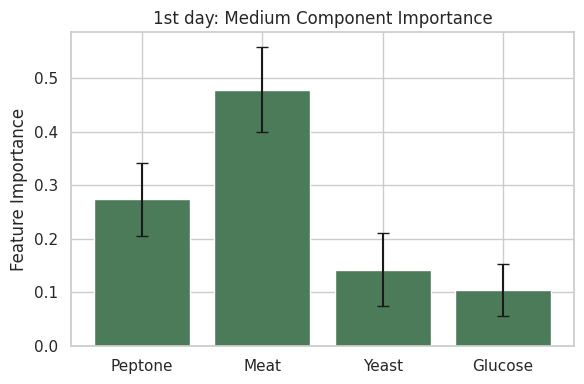

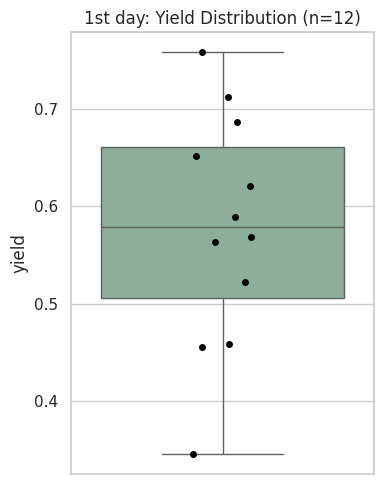

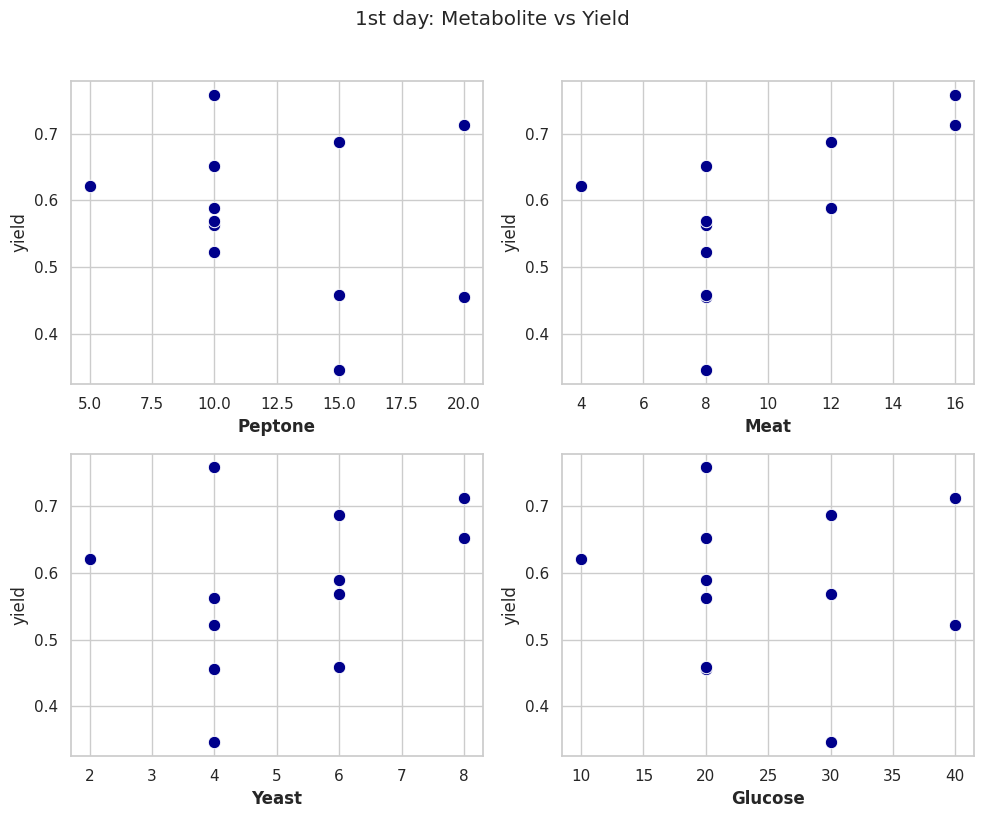

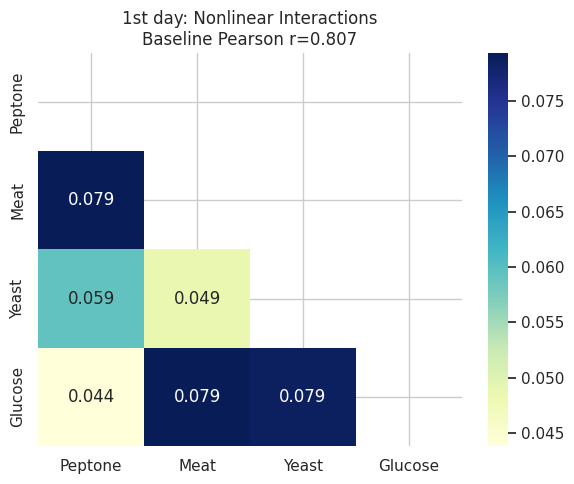

[2nd day] RandomizedSearchCV 학습 중...


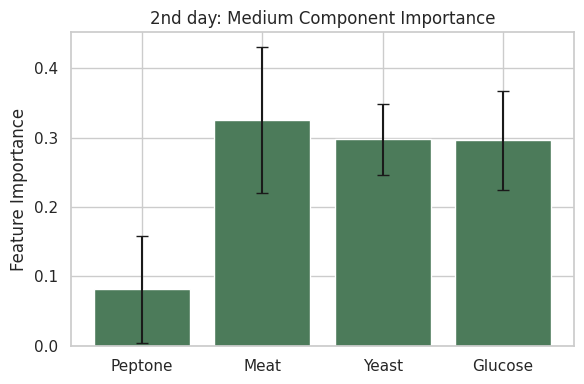

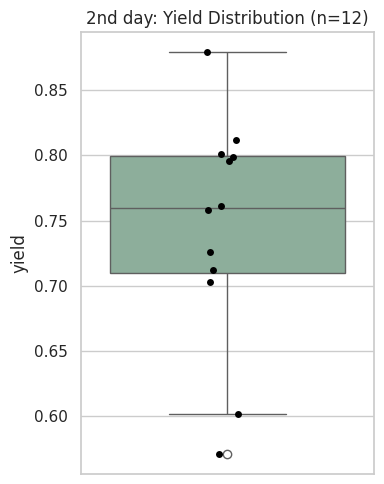

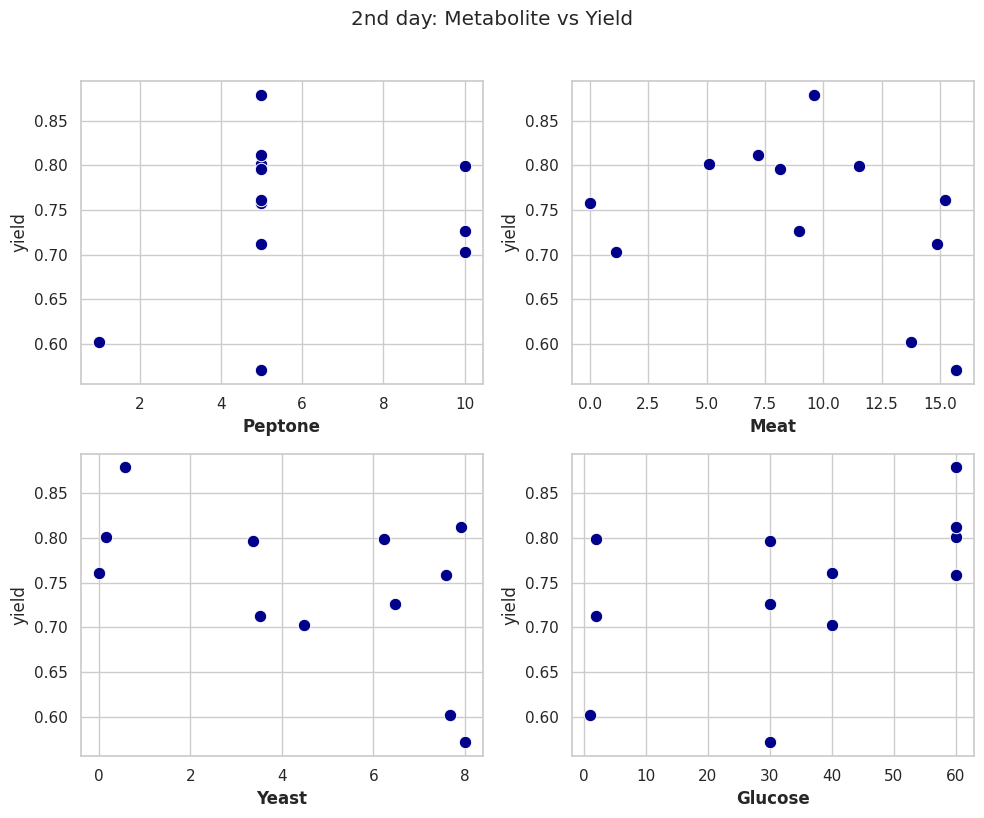

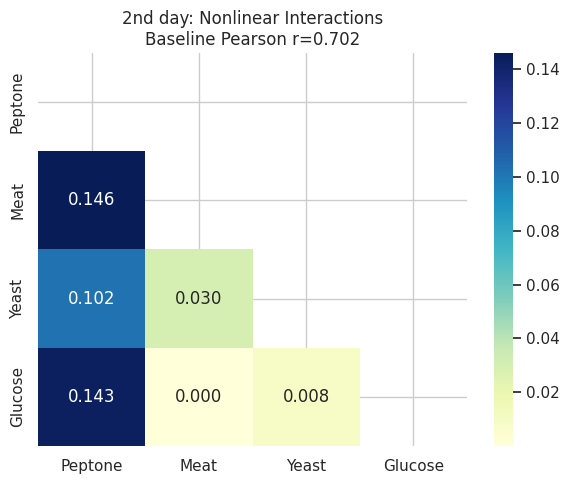

In [6]:
result_1st = analyze_one(day1, '1st day', OUT_DIR/'1st_day', recommendation_day=1)
result_2nd = analyze_one(day2, '2nd day', OUT_DIR/'2nd_day', recommendation_day=2)

## 날짜 간 직접 비교 그림

동일 축에서 두 날짜를 비교합니다. 데이터 행이 날짜 사이에 정확히 대응하지 않아도 작동합니다.

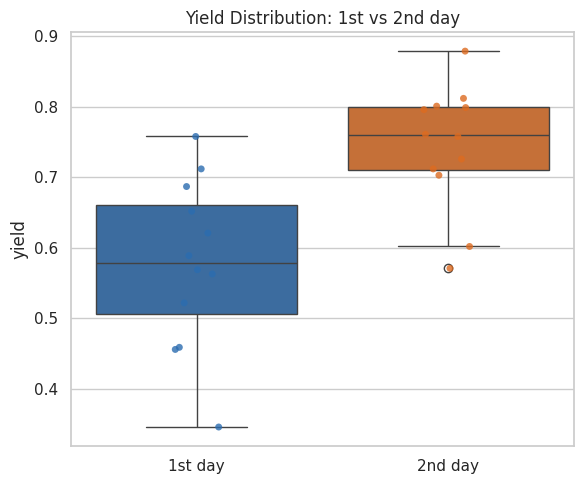

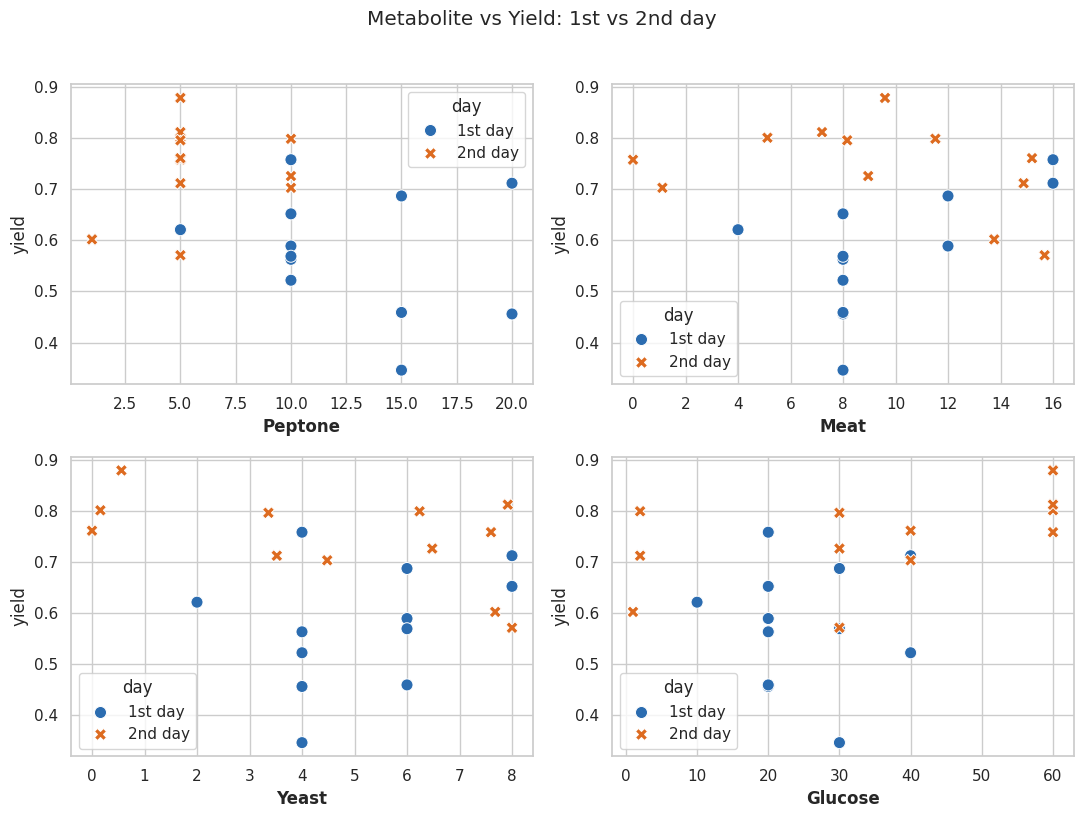

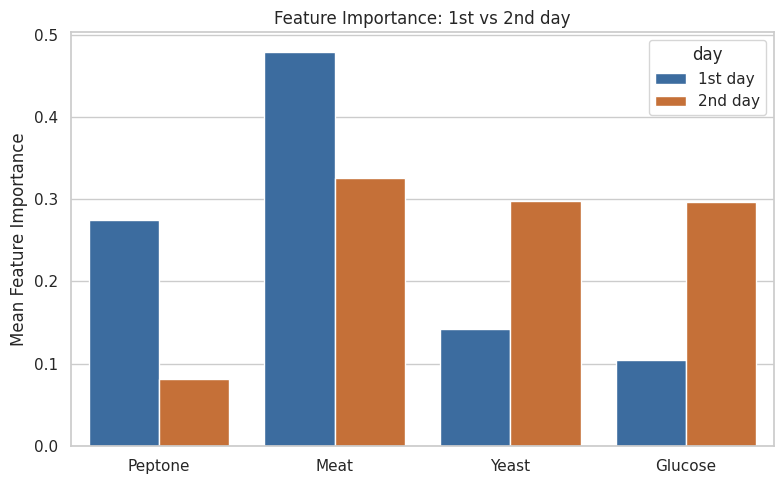

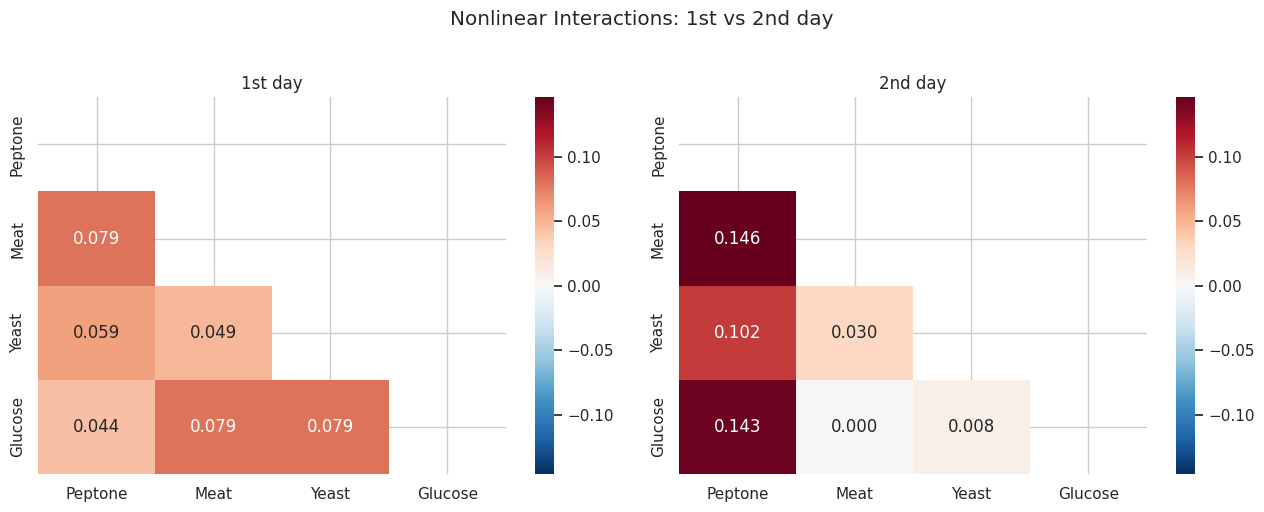

In [7]:
comparison_dir = OUT_DIR/'comparison'
both = pd.concat([day1, day2], ignore_index=True)
palette = {'1st day':'#2B6CB0', '2nd day':'#DD6B20'}

# 1) yield 분포 비교
fig, ax = plt.subplots(figsize=(6,5))
sns.boxplot(data=both, x='day', y='yield', hue='day', palette=palette, legend=False, ax=ax)
sns.stripplot(data=both, x='day', y='yield', hue='day', palette=palette, dodge=False, alpha=.8, ax=ax)
if ax.legend_ is not None: ax.legend_.remove()
ax.set(title='Yield Distribution: 1st vs 2nd day', xlabel='')
fig.tight_layout(); save_figure(fig, comparison_dir, 'Compare_Yield_Boxplot')

# 2) 성분별 산점도 비교
fig, axes = plt.subplots(2, 2, figsize=(11,8))
for feature, ax in zip(final_order, axes.flat):
    sns.scatterplot(data=both, x=feature, y='yield', hue='day', style='day', palette=palette, s=75, ax=ax)
    ax.set_xlabel(feature, fontweight='bold')
fig.suptitle('Metabolite vs Yield: 1st vs 2nd day', y=1.02)
fig.tight_layout(); save_figure(fig, comparison_dir, 'Compare_Metabolite_Yield_Scatter')

# 3) feature importance 비교
imp_compare = pd.concat([
    result_1st['importance'].assign(day='1st day'),
    result_2nd['importance'].assign(day='2nd day')], ignore_index=True)
imp_compare.to_csv(comparison_dir/'Compare_Feature_Importance.csv', index=False)
fig, ax = plt.subplots(figsize=(8,5))
sns.barplot(data=imp_compare, x='feature', y='importance_mean', hue='day', palette=palette, ax=ax)
ax.set(ylabel='Mean Feature Importance', xlabel='', title='Feature Importance: 1st vs 2nd day')
fig.tight_layout(); save_figure(fig, comparison_dir, 'Compare_Feature_Importance')

# 4) 상호작용을 같은 색 범위로 나란히 비교
vmax = max(result_1st['interactions'].abs().to_numpy().max(), result_2nd['interactions'].abs().to_numpy().max())
fig, axes = plt.subplots(1, 2, figsize=(13,5))
mask = np.triu(np.ones((len(final_order), len(final_order)), dtype=bool))
for ax, title, matrix in zip(axes, ['1st day', '2nd day'], [result_1st['interactions'], result_2nd['interactions']]):
    sns.heatmap(matrix, mask=mask, cmap='RdBu_r', center=0, vmin=-vmax, vmax=vmax, annot=True, fmt='.3f', ax=ax)
    ax.set_title(title)
fig.suptitle('Nonlinear Interactions: 1st vs 2nd day', y=1.02)
fig.tight_layout(); save_figure(fig, comparison_dir, 'Compare_Interactions')

## 1st day vs 2nd day 결과 해석

### 핵심 결론

2nd day는 1st day보다 **수율 수준이 전반적으로 높아졌고 결과의 변동성도 감소**했다. 다만 두 날짜에서 실험한 배지 조성의 범위와 분포가 다르므로, 이 차이를 순수한 시간 또는 날짜 효과로 해석하기보다는 **2nd day에서 더 유망한 조성 영역을 탐색한 결과**로 보는 것이 적절하다.

### 1. 수율 분포 비교

| 지표 | 1st day | 2nd day | 변화 |
|---|---:|---:|---:|
| 표본 수 | 12 | 12 | 동일 |
| 평균 yield | 0.578 | 0.743 | **+0.166 (약 28.6% 증가)** |
| 중앙값 | 0.579 | 0.760 | **+0.181** |
| 최솟값 | 0.346 | 0.571 | +0.225 |
| 최댓값 | 0.758 | 0.879 | +0.121 |
| 표준편차 | 0.119 | 0.088 | **감소** |

2nd day에서는 최고 수율만 증가한 것이 아니라 상자그림의 분포 전체가 위쪽으로 이동했다. 특히 최솟값이 0.346에서 0.571로 크게 개선되었으며, 표준편차도 감소하였다. 따라서 2nd day의 결과는 1st day보다 **전반적으로 높은 수율을 보이면서 조건 간 편차도 상대적으로 작아진 것**으로 해석할 수 있다.

### 2. Feature Importance 비교

| 성분 | 1st day | 2nd day | 주요 변화 |
|---|---:|---:|---|
| Peptone | 약 0.27 | 약 0.08 | 중요도 감소 |
| Meat | 약 0.48 | 약 0.33 | 두 날짜 모두 1위 |
| Yeast | 약 0.14 | 약 0.30 | 중요도 증가 |
| Glucose | 약 0.10 | 약 0.30 | 중요도 증가 |

1st day에서는 **Meat가 압도적으로 중요한 변수**였다. 초기 실험 범위에서는 Meat 농도의 차이가 수율 차이를 설명하는 데 가장 큰 역할을 한 것으로 보인다.

2nd day에서도 Meat가 가장 중요했지만, Yeast와 Glucose의 중요도가 크게 증가하여 Meat와 비슷한 수준에 도달했다. 따라서 2nd day에서는 특정 성분 하나보다 **Meat–Yeast–Glucose의 조합과 균형**이 수율을 결정하는 구조에 가까워졌다고 볼 수 있다.

Peptone의 중요도가 감소한 것을 Peptone이 생물학적으로 불필요하다는 의미로 해석해서는 안 된다. 2nd day에서는 Peptone 값이 주로 특정 농도에 집중되어 있어 변동 범위가 작기 때문에, 모델이 Peptone의 단독 효과를 학습하기 어려웠을 가능성이 있다. 또한 Feature Importance는 영향의 상대적 크기를 나타낼 뿐, **농도가 높을수록 좋은지 또는 낮을수록 좋은지와 같은 방향성은 나타내지 않는다.**

### 3. 성분별 산점도 해석

- **Glucose:** 2nd day의 Glucose 60 조건에서 0.76~0.879의 높은 수율이 다수 관찰되었다. 따라서 고농도 Glucose 영역이 유망하다는 신호가 있다. 하지만 Glucose 60에서도 약 0.57의 조건이 존재하므로, Glucose만 높이면 항상 수율이 증가하는 것은 아니다.
- **Yeast:** 2nd day에서는 낮은 Yeast 농도에서도 높은 수율이 관찰되었다. 낮은 Yeast와 적절한 Meat·Glucose 조합이 유망할 가능성이 있다.
- **Meat:** 두 날짜 모두 모델 중요도 1위였지만, 산점도에서는 Meat가 높아질수록 수율이 단조롭게 증가하는 형태가 나타나지 않았다. 따라서 단순한 고농도 효과보다 적정 농도 범위 또는 다른 성분과의 조합 효과를 고려해야 한다.
- **Peptone:** 2nd day 데이터가 일부 농도에 집중되어 있어 산점도만으로 Peptone의 독립적인 농도 효과를 판단하기 어렵다.

전체적으로는 **Glucose가 비교적 높고, Yeast가 낮거나 중간이며, Meat가 적절한 범위인 조합**이 후속 실험에서 우선 검토할 만한 영역으로 보인다.

### 4. 비선형 상호작용 비교

1st day에서는 성분 간 상호작용이 약 0.044~0.079 범위로 비교적 고르게 분포했다. 반면 2nd day에서는 다음 Peptone 관련 상호작용이 상대적으로 크게 나타났다.

- **Peptone × Meat: 0.146**
- **Peptone × Glucose: 0.143**
- **Peptone × Yeast: 0.102**
- Meat × Yeast: 0.030
- Yeast × Glucose: 0.008
- Meat × Glucose: 0.000

Peptone은 2nd day의 단독 Feature Importance는 낮았지만 Meat 및 Glucose와의 상호작용은 강했다. 이는 Peptone이 수율을 독립적으로 결정하기보다 **Meat나 Glucose의 효과가 나타나는 방식을 조절할 가능성**을 시사한다.

다만 이 상호작용 값은 날짜별 12개 관측치에 기반하며, 학습 데이터에서 계산한 탐색적 지표이다. 따라서 확정적인 생물학적 상호작용으로 표현하기보다는 **후속 검증 실험의 후보 가설**로 활용하는 것이 안전하다.

### 5. 종합 해석 및 주의점

> 2차 실험에서는 평균 수율이 1차 실험 대비 약 28.6% 증가했으며 결과의 변동성도 감소하였다. 1차 실험에서는 Meat가 지배적인 중요 변수였으나, 2차 실험에서는 Meat, Yeast 및 Glucose의 중요도가 비교적 균등해지면서 다성분 조합의 영향이 커졌다. 특히 고농도 Glucose와 낮거나 중간 수준의 Yeast를 포함한 일부 조성에서 높은 수율이 확인되었다. Peptone은 단독 중요도는 낮았지만 Meat 및 Glucose와 강한 상호작용을 보여 다른 성분의 효과를 조절하는 역할을 할 가능성이 제시되었다. 다만 날짜별 조성 탐색 범위가 다르고 각 데이터가 12개로 제한적이므로, 해당 결과는 최적화 방향을 제시하는 탐색적 근거로 해석해야 한다.

#### 해석 시 주의

1. 1st day와 2nd day의 배지 조성 분포가 다르므로, 수율 차이를 날짜 자체의 인과효과로 단정할 수 없다.
2. 표본 수가 각 12개로 작기 때문에 Feature Importance의 세부 순위와 상호작용 수치는 추가 데이터에 따라 바뀔 수 있다.
3. 높은 Feature Importance는 영향의 방향을 의미하지 않는다. 최종 최적 농도는 산점도, 추천 조성 및 후속 실험을 함께 검토해야 한다.

## 두 날짜 통합 모델

두 날짜의 모든 관측치를 합쳐 최종 모델을 학습합니다. 같은 배지 조성이 양쪽 CSV에 반복되어 있더라도 각각의 독립 관측값으로 유지합니다.

[Combined 1st + 2nd day] RandomizedSearchCV 학습 중...


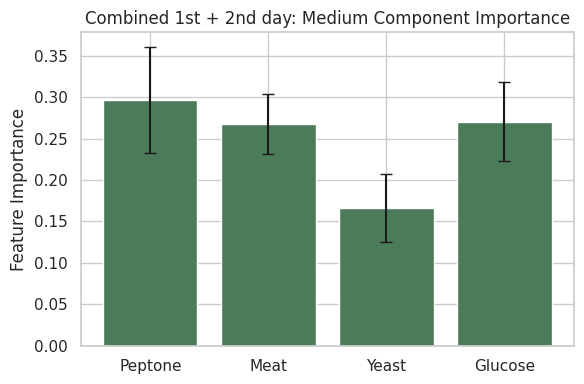

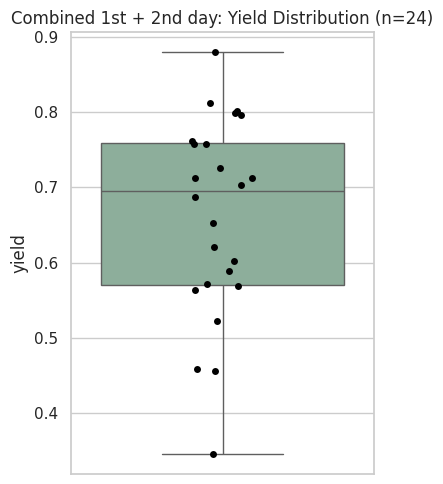

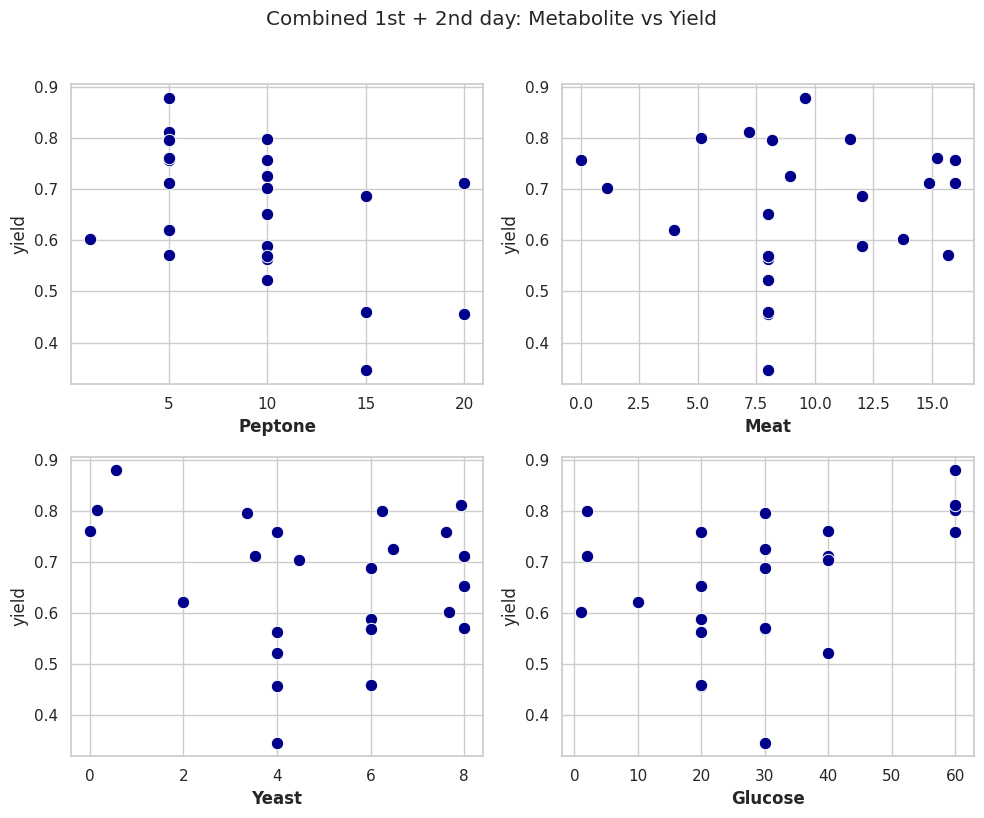

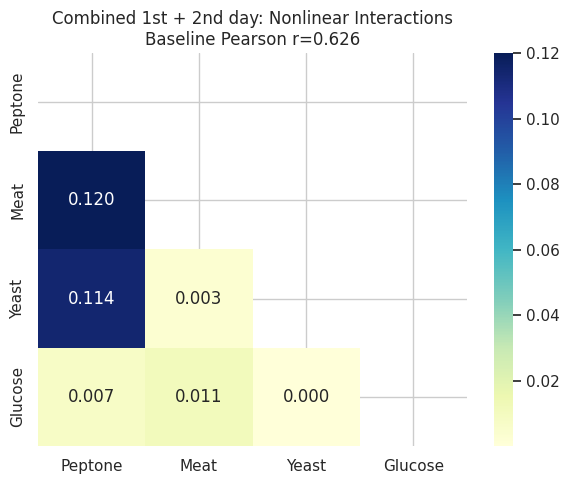

,day,count,mean,std,min,median,max
0,1st day,12,0.577833,0.119085,0.346,0.5790,0.758
1,2nd day,12,0.743333,0.088126,0.571,0.7595,0.879


In [8]:
combined = pd.concat([day1, day2], ignore_index=True)
combined.to_csv(OUT_DIR/'combined'/'Combined_Input_Data.csv', index=False)
result_combined = analyze_one(combined, 'Combined 1st + 2nd day', OUT_DIR/'combined', recommendation_day=2)

summary = both.groupby('day')['yield'].agg(['count','mean','std','min','median','max']).reset_index()
summary.to_csv(comparison_dir/'Yield_Summary_By_Day.csv', index=False)
display(summary)

## 완료 및 저장 파일 확인

아래 셀에서 Google Drive에 생성된 전체 결과 파일을 확인할 수 있습니다.

In [9]:
saved = sorted(str(p.relative_to(OUT_DIR)) for p in OUT_DIR.rglob('*') if p.is_file())
print(f'완료: {len(saved)}개 파일 저장')
print('\n'.join(saved))

완료: 53개 파일 저장
1st_day/Feature_Importance.png
1st_day/Feature_Importance.svg
1st_day/Interactions.png
1st_day/Interactions.svg
1st_day/Metabolite_Yield_Scatter.png
1st_day/Metabolite_Yield_Scatter.svg
1st_day/Next_Recommendations_Concentrations.csv
1st_day/Next_Recommendations_Volumes.csv
1st_day/Predicted_Top5.csv
1st_day/Yield_Boxplot.png
1st_day/Yield_Boxplot.svg
1st_day/cv_results.csv
1st_day/feature_importance.csv
1st_day/interactions.csv
2nd_day/Feature_Importance.png
2nd_day/Feature_Importance.svg
2nd_day/Interactions.png
2nd_day/Interactions.svg
2nd_day/Metabolite_Yield_Scatter.png
2nd_day/Metabolite_Yield_Scatter.svg
2nd_day/Next_Recommendations_Concentrations.csv
2nd_day/Next_Recommendations_Volumes.csv
2nd_day/Predicted_Top5.csv
2nd_day/Yield_Boxplot.png
2nd_day/Yield_Boxplot.svg
2nd_day/cv_results.csv
2nd_day/feature_importance.csv
2nd_day/interactions.csv
combined/Combined_Input_Data.csv
combined/Feature_Importance.png
combined/Feature_Importance.svg
combined/Interactions.p